In [1]:
##-------------START------------------------##

##<font color="blue"><b>-----Parameter Efficient Fine-Tuning Approaches and Learning Rate Schedulers-----</b></font>

### <font color="purple"><b>Problem Statement: Comparing Parameter Efficient Fine-Tuning Strategies and Effect of Learning-Rate Schedulers</b></font>

Pre-trained language models can be adapted to downstream tasks by updating different portions of their parameters and using different learning-rate schedules. However, the impact of **parameter-freezing strategies** and **learning-rate schedulers** on model performance and training efficiency needs to be understood.

In this experiment, we compare **Layer-Wise, Block-Wise, and Progressive Fine-Tuning** of DistilBERT and understand effect of multiple learning-rate schedulers, including **Linear, Cosine, Constant with Warmup, Polynomial, etc.**

---

### **Objective:**

The objective is to analyze how **which parameters are trained** and **how the learning rate changes during training** affect:

- **Task performance**
- **Number of trainable parameters**
- **Training behavior and efficiency**

The experiment therefore studies the **interaction between fine-tuning/freezing strategies and learning-rate schedulers** across NLP tasks.


### <font color="purple"><b>The Process Flow: </b></font>

<img src="https://raw.githubusercontent.com/Rekha215/Demo-Images/refs/heads/main/PEFT_Freeze.png" width="900">

In [2]:
import os
import time
import random
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from torch.utils.data import TensorDataset, DataLoader, Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [4]:
DATASET      = "nyu-mll/glue"
SUBSET       = "sst2"
MODEL_NAME   = "distilbert-base-uncased"
MAX_LEN      = 128
BATCH_SIZE   = 32
LR           = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.03       # can set as 10% (0.1)
EPOCHS       = 3
N_TRAIN      = 2000      # subsample of the 67k train split, to keep the demo short
N_LAYERS     = 6         # DistilBERT encoder depth
SEED         = 42

In [5]:
set_seed(SEED)

In [6]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("pad token:", tokenizer.pad_token, "| vocab size:", tokenizer.vocab_size)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

pad token: [PAD] | vocab size: 30522


In [7]:
sst2     = load_dataset(DATASET, SUBSET)
full_df  = sst2["train"].to_pandas()
val_df   = sst2["validation"].to_pandas()      # 872 labelled rows; the GLUE test split is unlabelled

train_df = full_df.sample(n=N_TRAIN, random_state=SEED).reset_index(drop=True)

print("Train/Val:", train_df.shape, val_df.shape)
print("Train label balance:", train_df["label"].value_counts().to_dict())

README.md:   0%|          | 0.00/35.3k [00:00<?, ?B/s]

sst2/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 3.11MB            

sst2/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

sst2/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 72.8kB            

sst2/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

sst2/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

Train/Val: (2000, 3) (872, 3)
Train label balance: {1: 1114, 0: 886}


In [8]:
train_df.head()

,sentence,label,idx
0,with outtakes in which most of the characters ...,0,66730
1,enigma is well-made,1,29890
2,is ) so stoked to make an important film about...,0,45801
3,the closest thing to the experience of space t...,1,29352
4,lose their luster,0,19858


In [9]:
val_df.head()

,sentence,label,idx
0,it 's a charming and often affecting journey .,1,0
1,unflinchingly bleak and desperate,0,1
2,allows us to hope that nolan is poised to emba...,1,2
3,"the acting , costumes , music , cinematography...",1,3
4,"it 's slow -- very , very slow .",0,4


In [10]:
# ===========================================================================
#    Build TensorDatasets
#    sentence -> input_ids + attention_mask   |   label -> labels
#    Fixed-length padding is required because TensorDataset needs equal shapes
# ===========================================================================
def build_dataset(df):
    enc = tokenizer(df["sentence"].tolist(), truncation=True, max_length=MAX_LEN, padding="max_length", return_tensors="pt",)
    labels = torch.tensor(df["label"].tolist(), dtype=torch.long)
    return TensorDataset(enc["input_ids"], enc["attention_mask"], labels)

train_ds = build_dataset(train_df)
val_ds   = build_dataset(val_df)

print("Sizes: ", len(train_ds), len(val_ds))
print("input_ids shape:", train_ds[0][0].shape)

Sizes:  2000 872
input_ids shape: torch.Size([128])


In [11]:
# ===========================================================================
# Wrap TensorDataset -> dict for Trainer
# ===========================================================================
class DictDataset(Dataset):
    def __init__(self, tensor_ds):
        self.ds = tensor_ds
    def __len__(self):
        return len(self.ds)
    def __getitem__(self, i):
        input_ids, attention_mask, labels = self.ds[i]
        return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels}

In [12]:
# just for understanding of modules of model
get_model_layers = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

print("=== MODEL ===")
print(get_model_layers.__class__.__name__)

print("\n=== ENCODER ===")
print(get_model_layers.distilbert.__class__.__name__)

print("\n=== EMBEDDINGS ===")
print(get_model_layers.distilbert.embeddings.__class__.__name__)

print("\n=== TRANSFORMER LAYERS ===")
for i, layer in enumerate(get_model_layers.distilbert.transformer.layer):
    print(f"Layer {i}: {layer.__class__.__name__}")

print("\n=== HEAD ===")
print("Pre-classifier:", get_model_layers.pre_classifier)
print("Classifier:", get_model_layers.classifier)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


=== MODEL ===
DistilBertForSequenceClassification

=== ENCODER ===
DistilBertModel

=== EMBEDDINGS ===
Embeddings

=== TRANSFORMER LAYERS ===
Layer 0: TransformerBlock
Layer 1: TransformerBlock
Layer 2: TransformerBlock
Layer 3: TransformerBlock
Layer 4: TransformerBlock
Layer 5: TransformerBlock

=== HEAD ===
Pre-classifier: Linear(in_features=768, out_features=768, bias=True)
Classifier: Linear(in_features=768, out_features=2, bias=True)


In [13]:
# ===========================================================================
# Model builder + freezing utilities
#   set_trainable(model, layers=(3, 4, 5))  ->  only blocks 3,4,5 + head train
#   freeze_bottom(model, k)                 ->  embeddings + blocks 0..k-1 frozen
# ===========================================================================
def build_model():
    set_seed(SEED)                     # identical classifier-head init in every run
    return AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

def set_trainable(model, layers=(), embeddings=False, head=True):
    for p in model.parameters():
        p.requires_grad = False

    for p in model.distilbert.embeddings.parameters():
        p.requires_grad = embeddings

    for i in layers:
        for p in model.distilbert.transformer.layer[i].parameters():
            p.requires_grad = True

    if head:
        for p in model.pre_classifier.parameters():
            p.requires_grad = True
        for p in model.classifier.parameters():
            p.requires_grad = True

    return model

def freeze_bottom(model, k):
    # k = number of earlier encoder blocks to freeze; embeddings stay trainable
    return set_trainable(model, layers=range(k, N_LAYERS), embeddings=True, head=True)

def param_stats(model):
    total     = sum(p.numel() for p in model.parameters())              # numel() in PyTorch means “number of elements.”
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return trainable, total, 100.0 * trainable / total

In [14]:
# ===========================================================================
# Metrics - used during training
# ===========================================================================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, preds), "f1_macro": f1_score(labels, preds, average="macro"),}

In [15]:
# ===========================================================================
# Reusable training
# ===========================================================================
def run_training(model, train_ds, val_ds, out_dir, lr=LR, epochs=EPOCHS, max_steps=-1, scheduler="linear", scheduler_kwargs=None,
                 warmup_ratio=WARMUP_RATIO, eval_strategy="epoch", eval_steps=None):
    args = TrainingArguments(
        output_dir=out_dir,
        num_train_epochs=epochs,
        max_steps=max_steps,                  # overrides num_train_epochs when > 0
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        learning_rate=lr,
        weight_decay=WEIGHT_DECAY,
        warmup_steps=warmup_ratio,            # transformers v5: float in [0,1) = ratio of total steps
        lr_scheduler_type=scheduler,
        lr_scheduler_kwargs=scheduler_kwargs or {},
        fp16=torch.cuda.is_available(),
        logging_strategy="steps",             # log train loss + LR every 25 steps
        logging_steps=5,
        eval_strategy=eval_strategy,          # "epoch" everywhere except plateau
        eval_steps=eval_steps,                # only used when eval_strategy="steps"
        save_strategy="no",
        remove_unused_columns=False,          # required: DictDataset has no columns
        report_to=[],
        seed=SEED,
    )
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=DictDataset(train_ds),
        eval_dataset=DictDataset(val_ds),
        compute_metrics=compute_metrics,
    )
    t0 = time.time()
    trainer.train()
    trainer.minutes = round((time.time() - t0) / 60, 2)
    metrics = trainer.evaluate()
    print(f"\nFinal validation metrics ({out_dir}):", metrics)
    return trainer

In [16]:
# ===========================================================================
# Result book-keeping
# ===========================================================================
RESULTS = []

def record_result(trainer, model, approach, config):
    m = trainer.evaluate()
    trainable, total, pct = param_stats(model)
    RESULTS.append({
        "approach"    : approach,
        "config"      : config,
        "accuracy"    : round(m["eval_accuracy"], 4),
        "f1_macro"    : round(m["eval_f1_macro"], 4),
        "eval_loss"   : round(m["eval_loss"], 4),
        "trainable_M" : round(trainable / 1e6, 1),
        "trainable_%" : round(pct, 1),
        "steps"       : trainer.state.global_step,
        "minutes"     : getattr(trainer, "minutes", None),
    })
    return RESULTS[-1]  # return the most recently added result

In [17]:
# ===========================================================================
# Classification report on the validation set
# ===========================================================================
def classification_report_for(trainer, dataset, title=""):
    out    = trainer.predict(DictDataset(dataset))
    y_true = out.label_ids
    y_pred = out.predictions.argmax(-1)

    print("=" * 80)
    print("Classification report:", title)
    print("=" * 80)
    print(classification_report(y_true, y_pred, target_names=["negative", "positive"], digits=4))

    report = classification_report(y_true, y_pred, target_names=["negative", "positive"], digits=4, output_dict=True)
    return pd.DataFrame(report).T

In [18]:
# ===========================================================================
# Curve helpers (read Trainer.state.log_history)
# ===========================================================================
def get_lr_curve(trainer):
    steps, lrs = [], []
    for rec in trainer.state.log_history:   # read rec as record
        if "learning_rate" in rec:
            steps.append(rec["step"])
            lrs.append(rec["learning_rate"])
    return steps, lrs

def get_loss_curves(trainer):
    train_steps, train_loss = [], []
    val_steps,   val_acc    = [], []
    for rec in trainer.state.log_history:
        if "loss" in rec and "eval_loss" not in rec:
            train_steps.append(rec["step"])
            train_loss.append(rec["loss"])
        if "eval_accuracy" in rec:
            val_steps.append(rec["step"])
            val_acc.append(rec["eval_accuracy"])
    return train_steps, train_loss, val_steps, val_acc

### <font color="purple">**Approach 1: SFT (full supervised fine-tuning)**</font>

In [19]:
# --- Approach 1: SFT as Baseline ---
print("=" * 80)
print("APPROACH 1  |  SFT (all parameters trainable)")
print("=" * 80)

sft_model = build_model()
set_trainable(sft_model, layers=range(N_LAYERS), embeddings=True, head=True)

trainable, total, pct = param_stats(sft_model)
print(f"Trainable: {trainable/1e6:.1f}M / {total/1e6:.1f}M  ({pct:.1f}%)")

sft_trainer = run_training(sft_model, train_ds, val_ds, "./a1_sft", scheduler="linear")
record_result(sft_trainer, sft_model, "1-SFT", "linear (baseline)")

APPROACH 1  |  SFT (all parameters trainable)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable: 67.0M / 67.0M  (100.0%)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.363354,0.387088,0.836009,0.836004
2,0.248035,0.364782,0.849771,0.849626
3,0.216329,0.379920,0.845183,0.845076


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.216329,0.379920,3,0.845183,0.845076



Final validation metrics (./a1_sft): {'eval_loss': 0.3799196779727936, 'eval_accuracy': 0.8451834862385321, 'eval_f1_macro': 0.8450757052332353}


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.216329,0.379920,3,0.845183,0.845076


{'approach': '1-SFT',
 'config': 'linear (baseline)',
 'accuracy': 0.8452,
 'f1_macro': 0.8451,
 'eval_loss': 0.3799,
 'trainable_M': 67.0,
 'trainable_%': 100.0,
 'steps': 189,
 'minutes': 0.12}

In [20]:
steps_per_epoch = int(np.ceil(len(train_ds) / BATCH_SIZE))
TOTAL_STEPS     = steps_per_epoch * EPOCHS
print("Steps per epoch:", steps_per_epoch, "| total step budget:", TOTAL_STEPS)

Steps per epoch: 63 | total step budget: 189


### <font color="purple">**Approach 2: SFT by freezing the bottom (earlier) encoder layers**</font>

In [21]:
# --- Approach 2: freeze the bottom k encoder layers ---
FREEZE_CONFIGS = [0, 1, 2, 3, 4, 5, 6]      # k = number of earlier blocks frozen
freeze_trainers = {}

for k in FREEZE_CONFIGS:
    model = build_model()
    freeze_bottom(model, k)
    trainable, total, pct = param_stats(model)

    print("=" * 80)
    print(f"APPROACH 2  |  freeze bottom {k}  ->  training blocks {list(range(k, N_LAYERS))} + head")
    print(f"Trainable: {trainable/1e6:.1f}M / {total/1e6:.1f}M  ({pct:.1f}%)")
    print("=" * 80)

    trainer = run_training(model, train_ds, val_ds, f"./a2{k}", scheduler="linear")
    freeze_trainers[k] = trainer
    record_result(trainer, model, "encoder-freezing", f"freeze-{k}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


APPROACH 2  |  freeze bottom 0  ->  training blocks [0, 1, 2, 3, 4, 5] + head
Trainable: 67.0M / 67.0M  (100.0%)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.363354,0.387088,0.836009,0.836004
2,0.248035,0.364782,0.849771,0.849626
3,0.216329,0.379920,0.845183,0.845076


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.216329,0.379920,3,0.845183,0.845076


...

APPROACH 2  |  freeze bottom 6  ->  training blocks [] + head
Trainable: 24.4M / 67.0M  (36.5%)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.670044,0.677743,0.509174,0.337386
2,0.651060,0.662384,0.528670,0.380004
3,0.640150,0.655295,0.556193,0.440149


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.640150,0.655295,3,0.556193,0.440149



Final validation metrics (./a26): {'eval_loss': 0.6552952527999878, 'eval_accuracy': 0.5561926605504587, 'eval_f1_macro': 0.44014930944382236}


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.640150,0.655295,3,0.556193,0.440149


In [22]:
# ==========================================================================================
# What is trainable?   baseline (SFT) vs each freeze-k-encoders   [model.named_parameters()]
# ==========================================================================================
BLOCK_ORDER = ["embeddings"] + [f"layer{i}" for i in range(N_LAYERS)] + ["head"]

def block_of(name):
    if "embeddings" in name:
        return "embeddings"
    if ".layer." in name:
        return "layer" + name.split(".layer.")[1].split(".")[0]
    return "head"

def trainable_blocks(model):
    status = {}
    for name, p in model.named_parameters():
        b = block_of(name)
        status[b] = status.get(b, False) or p.requires_grad
    return status

compare = pd.DataFrame(index=BLOCK_ORDER)
compare["baseline_SFT"] = ["TRAIN" if trainable_blocks(sft_model)[b] else "frozen" for b in BLOCK_ORDER]
for k in FREEZE_CONFIGS:
    st = trainable_blocks(freeze_trainers[k].model)
    compare[f"freeze-{k}-enocders"] = ["TRAIN" if st[b] else "frozen" for b in BLOCK_ORDER]

print("Block-level trainability")
print(compare.to_string())

Block-level trainability
           baseline_SFT freeze-0-enocders freeze-1-enocders freeze-2-enocders freeze-3-enocders freeze-4-enocders freeze-5-enocders freeze-6-enocders
embeddings        TRAIN             TRAIN             TRAIN             TRAIN             TRAIN             TRAIN             TRAIN             TRAIN
layer0            TRAIN             TRAIN            frozen            frozen            frozen            frozen            frozen            frozen
layer1            TRAIN             TRAIN             TRAIN            frozen            frozen            frozen            frozen            frozen
layer2            TRAIN             TRAIN             TRAIN             TRAIN            frozen            frozen            frozen            frozen
layer3            TRAIN             TRAIN             TRAIN             TRAIN             TRAIN            frozen            frozen            frozen
layer4            TRAIN             TRAIN             TRAIN             TRA

In [23]:
# --- Trainable parameter count, against the SFT baseline ---
base = sum(p.numel() for _, p in sft_model.named_parameters() if p.requires_grad)

for k in [None] + FREEZE_CONFIGS:
    m    = sft_model if k is None else freeze_trainers[k].model
    tag  = "baseline_SFT" if k is None else f"freeze-{k}-encoders"
    tr   = sum(p.numel() for _, p in m.named_parameters() if p.requires_grad)
    tsr  = [n for n, p in m.named_parameters() if p.requires_grad]
    print(f"{tag:<14} {tr/1e6:5.1f}M trainable  ({100*tr/base:5.1f}% of baseline)  "
          f"| {len(tsr):>3} tensors | first: {tsr[0]}")

baseline_SFT    67.0M trainable  (100.0% of baseline)  | 104 tensors | first: distilbert.embeddings.word_embeddings.weight
freeze-0-encoders  67.0M trainable  (100.0% of baseline)  | 104 tensors | first: distilbert.embeddings.word_embeddings.weight
freeze-1-encoders  59.9M trainable  ( 89.4% of baseline)  |  88 tensors | first: distilbert.embeddings.word_embeddings.weight
freeze-2-encoders  52.8M trainable  ( 78.8% of baseline)  |  72 tensors | first: distilbert.embeddings.word_embeddings.weight
freeze-3-encoders  45.7M trainable  ( 68.2% of baseline)  |  56 tensors | first: distilbert.embeddings.word_embeddings.weight
freeze-4-encoders  38.6M trainable  ( 57.7% of baseline)  |  40 tensors | first: distilbert.embeddings.word_embeddings.weight
freeze-5-encoders  31.5M trainable  ( 47.1% of baseline)  |  24 tensors | first: distilbert.embeddings.word_embeddings.weight
freeze-6-encoders  24.4M trainable  ( 36.5% of baseline)  |   8 tensors | first: distilbert.embeddings.word_embeddings.we

In [24]:
freeze_df = pd.DataFrame([r for r in RESULTS if r["approach"] == "encoder-freezing"])
print(freeze_df.to_string(index=False))

        approach   config  accuracy  f1_macro  eval_loss  trainable_M  trainable_%  steps  minutes
encoder-freezing freeze-0    0.8452    0.8451     0.3799         67.0        100.0    189     0.10
encoder-freezing freeze-1    0.8475    0.8474     0.3673         59.9         89.4    189     0.09
encoder-freezing freeze-2    0.8372    0.8372     0.3700         52.8         78.8    189     0.09
encoder-freezing freeze-3    0.8440    0.8440     0.3670         45.7         68.2    189     0.09
encoder-freezing freeze-4    0.8406    0.8405     0.3539         38.6         57.7    189     0.08
encoder-freezing freeze-5    0.8360    0.8360     0.4401         31.5         47.1    189     0.08
encoder-freezing freeze-6    0.5562    0.4401     0.6553         24.4         36.5    189     0.08


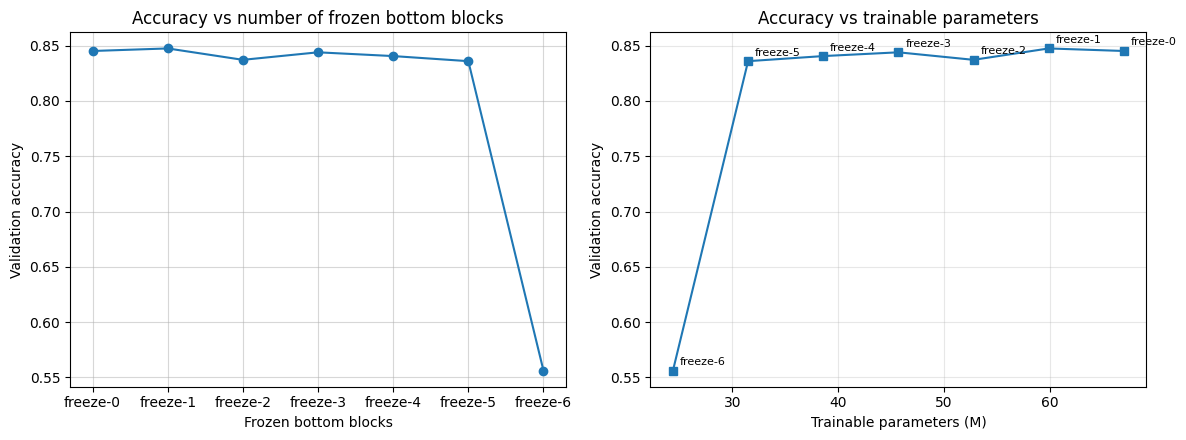

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(freeze_df["config"], freeze_df["accuracy"], marker="o")
axes[0].set_title("Accuracy vs number of frozen bottom blocks")
axes[0].set_xlabel("Frozen bottom blocks")
axes[0].set_ylabel("Validation accuracy")
axes[0].grid(True, alpha=0.5)

axes[1].plot(freeze_df["trainable_M"], freeze_df["accuracy"], marker="s")
for _, r in freeze_df.iterrows():
    axes[1].annotate(r["config"], (r["trainable_M"], r["accuracy"]), fontsize=8, xytext=(5, 4), textcoords="offset points")
axes[1].set_title("Accuracy vs trainable parameters")
axes[1].set_xlabel("Trainable parameters (M)")
axes[1].set_ylabel("Validation accuracy")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### <font color="purple">**Approach 3: block-wise freezing — one block at a time**</font>

| Tag | Block |
|---|---|
| `block1` | `embeddings` |
| `block2` | `encoders`   |
| `block3` | `classifier-head`   |

Each run is a leave-one-out ablation against the Approach 1 baseline: if freezing a block costs almost nothing, that block was contributing little to the task; if accuracy drops, that block was doing real work.

In [26]:
# ===========================================================================
# Block-wise freezing: freeze exactly ONE block, everything else trains
#   block1 -> embeddings
#   block2 -> encoders   (all 6 transformer layers together)
#   block3 -> classifier-head  (pre_classifier + classifier)
# ===========================================================================
BLOCKS = [
    ("block1", "embeddings"),
    ("block2", "encoders"),
    ("block3", "classifier-head"),
]

def block_modules(model, block):
    if block == "embeddings":
        return [model.distilbert.embeddings]
    if block == "encoders":
        return list(model.distilbert.transformer.layer)
    if block == "classifier-head":
        return [model.pre_classifier, model.classifier]
    raise ValueError(f"unknown block: {block}")

def freeze_one_block(model, block):
    # start from full SFT (everything trainable), then switch off a single block
    set_trainable(model, layers=range(N_LAYERS), embeddings=True, head=True)

    for m in block_modules(model, block):
        for p in m.parameters():
            p.requires_grad = False

    return model

print(pd.DataFrame(BLOCKS, columns=["tag", "block"]).to_string(index=False))

   tag           block
block1      embeddings
block2        encoders
block3 classifier-head


In [27]:
# --- freeze one block at a time ---
blockwise_trainers = {}

for tag, block in BLOCKS:
    model = build_model()
    freeze_one_block(model, block)
    trainable, total, pct = param_stats(model)

    print("=" * 80)
    print(f"APPROACH 3  |  {tag} frozen ({block})  ->  every other block + head trains")
    print(f"Trainable: {trainable/1e6:.1f}M / {total/1e6:.1f}M  ({pct:.1f}%)")
    print("=" * 80)

    trainer = run_training(model, train_ds, val_ds, f"./a3{block}", scheduler="linear")
    blockwise_trainers[block] = trainer
    record_result(trainer, model, "block-wise-freezing", f"{tag}_{block}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


APPROACH 3  |  block1 frozen (embeddings)  ->  every other block + head trains
Trainable: 43.1M / 67.0M  (64.4%)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.363708,0.386713,0.836009,0.835999
2,0.249947,0.362935,0.849771,0.849666
3,0.225119,0.374740,0.845183,0.845076


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.225119,0.374740,3,0.845183,0.845076


...

APPROACH 3  |  block3 frozen (classifier-head)  ->  every other block + head trains
Trainable: 66.4M / 67.0M  (99.1%)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.434744,0.438417,0.824541,0.824489
2,0.271191,0.381879,0.841743,0.841580
3,0.256782,0.378291,0.845183,0.845110


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.256782,0.378291,3,0.845183,0.845110



Final validation metrics (./a3classifier-head): {'eval_loss': 0.3782912790775299, 'eval_accuracy': 0.8451834862385321, 'eval_f1_macro': 0.8451099506199155}


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.256782,0.378291,3,0.845183,0.845110


In [28]:
# --- What is trainable? baseline vs one-block-frozen  [model.named_parameters()] ---
compare_bw = pd.DataFrame(index=BLOCK_ORDER)
compare_bw["baseline_SFT"] = ["TRAIN" if trainable_blocks(sft_model)[b] else "frozen" for b in BLOCK_ORDER]

for tag, block in BLOCKS:
    st = trainable_blocks(blockwise_trainers[block].model)
    compare_bw[tag] = ["TRAIN" if st[b] else "frozen" for b in BLOCK_ORDER]

print("Block-level trainability - exactly one block frozen per column")
print(compare_bw.to_string())

Block-level trainability - exactly one block frozen per column
           baseline_SFT  block1  block2  block3
embeddings        TRAIN  frozen   TRAIN   TRAIN
layer0            TRAIN   TRAIN  frozen   TRAIN
layer1            TRAIN   TRAIN  frozen   TRAIN
layer2            TRAIN   TRAIN  frozen   TRAIN
layer3            TRAIN   TRAIN  frozen   TRAIN
layer4            TRAIN   TRAIN  frozen   TRAIN
layer5            TRAIN   TRAIN  frozen   TRAIN
head              TRAIN   TRAIN   TRAIN  frozen


In [29]:
# --- Trainable parameter count, against the SFT baseline ---
base = sum(p.numel() for _, p in sft_model.named_parameters() if p.requires_grad)

for tag, block in [(None, None)] + BLOCKS:
    m   = sft_model if block is None else blockwise_trainers[block].model
    lbl = "baseline_SFT" if block is None else f"{tag} ({block})"
    tr  = sum(p.numel() for _, p in m.named_parameters() if p.requires_grad)
    tsr = [n for n, p in m.named_parameters() if p.requires_grad]
    print(f"{lbl:<20} {tr/1e6:5.1f}M trainable  ({100*tr/base:5.1f}% of baseline)  | {len(tsr):>3} tensors")

baseline_SFT          67.0M trainable  (100.0% of baseline)  | 104 tensors
block1 (embeddings)   43.1M trainable  ( 64.4% of baseline)  | 100 tensors
block2 (encoders)     24.4M trainable  ( 36.5% of baseline)  |   8 tensors
block3 (classifier-head)  66.4M trainable  ( 99.1% of baseline)  | 100 tensors


In [30]:
# --- Accuracy cost of freezing each single block ---
base_acc = [r for r in RESULTS if r["approach"] == "1-SFT"][0]["accuracy"]

bw_df = pd.DataFrame([r for r in RESULTS if r["approach"] == "block-wise-freezing"]).copy()
bw_df["frozen_block"] = [block for _, block in BLOCKS]
bw_df["delta_vs_SFT"] = (bw_df["accuracy"] - base_acc).round(4)

print("Baseline SFT accuracy:", base_acc, "\n")
print(bw_df[["config", "frozen_block", "accuracy", "delta_vs_SFT","trainable_M", "trainable_%", "minutes"]].to_string(index=False))

Baseline SFT accuracy: 0.8452 

                config    frozen_block  accuracy  delta_vs_SFT  trainable_M  trainable_%  minutes
     block1_embeddings      embeddings    0.8452         0.000         43.1         64.4     0.09
       block2_encoders        encoders    0.5562        -0.289         24.4         36.5     0.08
block3_classifier-head classifier-head    0.8452         0.000         66.4         99.1     0.09


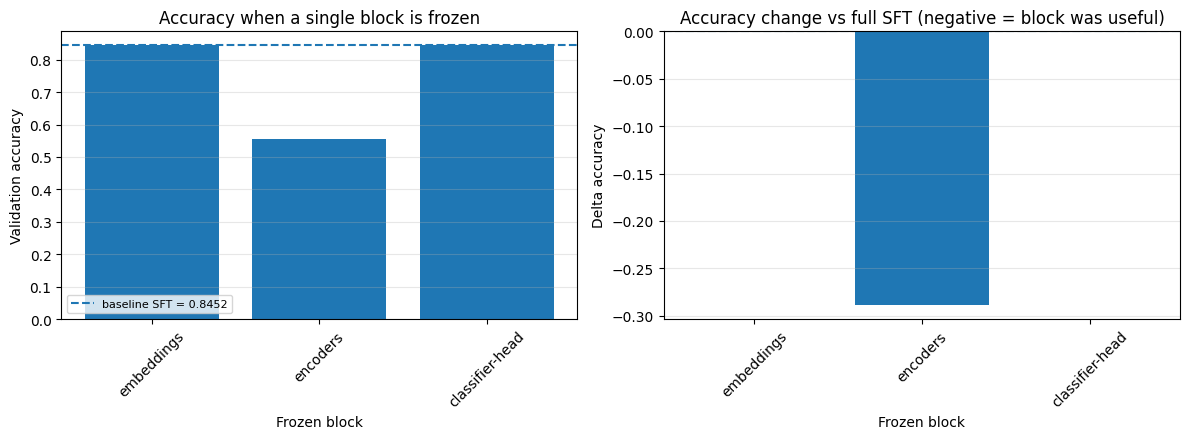

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(bw_df["frozen_block"], bw_df["accuracy"])
axes[0].axhline(base_acc, linestyle="--", label=f"baseline SFT = {base_acc:.4f}")
axes[0].set_title("Accuracy when a single block is frozen")
axes[0].set_xlabel("Frozen block")
axes[0].set_ylabel("Validation accuracy")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(fontsize=8)
axes[0].grid(True, axis="y", alpha=0.3)

axes[1].bar(bw_df["frozen_block"], bw_df["delta_vs_SFT"])
axes[1].axhline(0, linestyle="--")
axes[1].set_title("Accuracy change vs full SFT (negative = block was useful)")
axes[1].set_xlabel("Frozen block")
axes[1].set_ylabel("Delta accuracy")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### <font color="purple">**Approach 4: Progressive fine-tuning (gradual unfreezing)**</font>

Training begins with the classifier head only. One encoder block is unfrozen per stage, from the top down, and the embeddings are unfrozen in the final stage.

In [32]:
# --- Approach 4: progressive fine-tuning ---
STAGES = [
    ("S0_head",     (),               False),
    ("S1_+L5",      (5,),             False),
    ("S2_+L4",      (4, 5),           False),
    ("S3_all+emb",  tuple(range(6)),  True),
]

steps_per_stage = TOTAL_STEPS // len(STAGES)
print("Total budget:", TOTAL_STEPS, "| steps per stage:", steps_per_stage)

prog_model = build_model()
used, stage_rows, stage_minutes, prog_trainer = 0, [], [], None

for s, (name, layers, emb) in enumerate(STAGES):
    n_steps = steps_per_stage if s < len(STAGES) - 1 else TOTAL_STEPS - used
    set_trainable(prog_model, layers=layers, embeddings=emb, head=True)
    trainable, total, pct = param_stats(prog_model)

    print("=" * 80)
    print(f"APPROACH 4  |  {name}  |  {n_steps} steps  |  trainable {pct:.1f}%")
    print("=" * 80)

    prog_trainer = run_training(prog_model, train_ds, val_ds, f"./a4_{name}", max_steps=n_steps, scheduler="linear")
    used += n_steps
    stage_minutes.append(prog_trainer.minutes)
    stage_rows.append({
        "stage"       : name,
        "cum_steps"   : used,
        "trainable_%" : round(pct, 1),
        "accuracy"    : round(prog_trainer.evaluate()["eval_accuracy"], 4),
    })

stage_df = pd.DataFrame(stage_rows)
print(stage_df.to_string(index=False))

# the recorded row must reflect the whole schedule, not just the final stage
row = record_result(prog_trainer, prog_model, "progressive-FT", f"{len(STAGES)} stages")
row["steps"]   = TOTAL_STEPS
row["minutes"] = round(sum(stage_minutes), 2)

Total budget: 189 | steps per stage: 47


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


APPROACH 4  |  S0_head  |  47 steps  |  trainable 0.9%


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
0,0.681665,0.688095,0.509174,0.337386


...

Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.235454,0.360380,0,0.836009,0.835999



Final validation metrics (./a4_S3_all+emb): {'eval_loss': 0.3603804409503937, 'eval_accuracy': 0.8360091743119266, 'eval_f1_macro': 0.8359986058776723}


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.235454,0.360380,0,0.836009,0.835999


     stage  cum_steps  trainable_%  accuracy
   S0_head         47          0.9    0.5092
    S1_+L5         94         11.5    0.6365
    S2_+L4        141         22.1    0.8154
S3_all+emb        189        100.0    0.8360


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.235454,0.360380,0,0.836009,0.835999


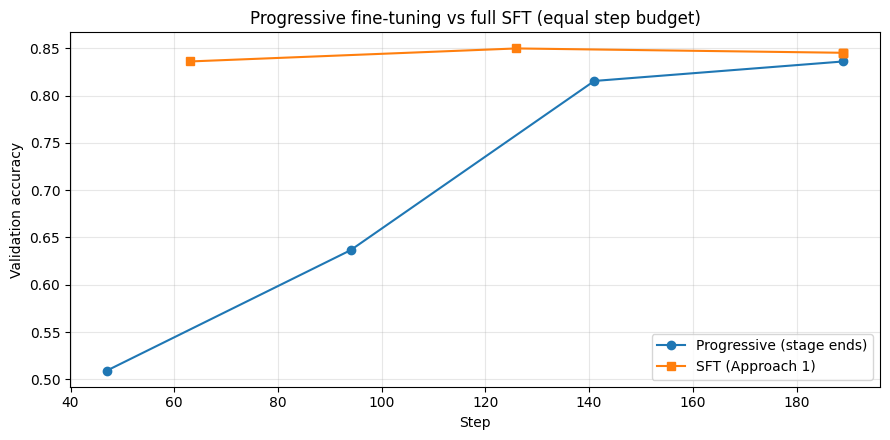

In [33]:
_, _, sft_steps, sft_acc = get_loss_curves(sft_trainer)

plt.figure(figsize=(9, 4.5))
plt.plot(stage_df["cum_steps"], stage_df["accuracy"], marker="o", label="Progressive (stage ends)")
plt.plot(sft_steps, sft_acc, marker="s", label="SFT (Approach 1)")
plt.title("Progressive fine-tuning vs full SFT (equal step budget)")
plt.xlabel("Step")
plt.ylabel("Validation accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### <font color="purple">**Approach 5: Effect of LR schedulers**</font>

Full fine-tuning is repeated with the four schedules used most often for transformer fine-tuning:

| Scheduler | Shape |
|---|---|
| `linear` | warmup, then linear decay to zero — the HuggingFace default |
| `cosine` | warmup, then cosine decay to zero |
| `constant_with_warmup` | warmup, then held flat |
| `polynomial` | warmup, then polynomial decay (`power=2.0` here) |

Only `lr_scheduler_type` changes between runs, so any difference comes from the schedule alone.

In [34]:
# --- Approach 5: the popular LR schedulers (six shapes + polynomial) ---
#   warmup_stable_decay needs num_decay_steps explicitly -> derive from the budget
DECAY_STEPS = int(0.20 * TOTAL_STEPS)      # last 20% of training decays

SCHEDULERS = [
    ("constant_with_warmup", {}),                                        # flat after warmup
    ("linear",               {}),                                        # linear decay to 0
    ("cosine",               {}),                                        # cosine decay to 0
    ("reduce_lr_on_plateau", {"factor": 0.5, "patience": 0}),            # step decay, val-driven
    ("cosine_with_restarts", {"num_cycles": 3}),                         # 3 hard restarts
    ("warmup_stable_decay",  {"num_decay_steps": DECAY_STEPS}),          # WSD: warmup-stable-decay
    ("polynomial",           {"power": 2.0}),                            # quadratic decay
]

sched_trainers = {}      # every schedule is trained here, so only the schedule differs

for name, kwargs in SCHEDULERS:
    print("=" * 80)
    print("APPROACH 5  |  scheduler =", name, "|", kwargs if kwargs else "(no extra kwargs)")
    print("=" * 80)

    # plateau is metric-driven: it can only drop the LR when an evaluation runs
    extra = {"eval_strategy": "steps", "eval_steps": 10} if name == "reduce_lr_on_plateau" else {}

    model = build_model()
    set_trainable(model, layers=range(N_LAYERS), embeddings=True, head=True)

    trainer = run_training(model, train_ds, val_ds, f"./a5_{name}", scheduler=name, scheduler_kwargs=kwargs, **extra)
    sched_trainers[name] = trainer
    record_result(trainer, model, "schedulers", name)

APPROACH 5  |  scheduler = constant_with_warmup | (no extra kwargs)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.355757,0.373747,0.838303,0.838303
2,0.224004,0.354521,0.853211,0.853162
3,0.183435,0.413489,0.855505,0.855285


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.183435,0.413489,3,0.855505,0.855285


...

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.389235,0.409043,0.826835,0.826753
2,0.273039,0.369612,0.833716,0.833710
3,0.279839,0.369861,0.842890,0.842880


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.279839,0.369861,3,0.842890,0.842880



Final validation metrics (./a5_polynomial): {'eval_loss': 0.3698606789112091, 'eval_accuracy': 0.8428899082568807, 'eval_f1_macro': 0.8428797832534344}


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.279839,0.369861,3,0.842890,0.842880


In [35]:
sched_df = pd.DataFrame([r for r in RESULTS if r["approach"] == "schedulers"])
print(sched_df.to_string(index=False))

BEST_SCHEDULER = sched_df.loc[sched_df["accuracy"].idxmax(), "config"]
print("\nBest scheduler ->", BEST_SCHEDULER)

  approach               config  accuracy  f1_macro  eval_loss  trainable_M  trainable_%  steps  minutes
schedulers constant_with_warmup    0.8555    0.8553     0.4135         67.0        100.0    189     0.10
schedulers               linear    0.8452    0.8451     0.3799         67.0        100.0    189     0.10
schedulers               cosine    0.8521    0.8520     0.3613         67.0        100.0    189     0.10
schedulers reduce_lr_on_plateau    0.8521    0.8521     0.3659         67.0        100.0    189     0.17
schedulers cosine_with_restarts    0.8567    0.8566     0.3585         67.0        100.0    189     0.10
schedulers  warmup_stable_decay    0.8463    0.8459     0.4732         67.0        100.0    189     0.10
schedulers           polynomial    0.8429    0.8429     0.3699         67.0        100.0    189     0.10

Best scheduler -> cosine_with_restarts


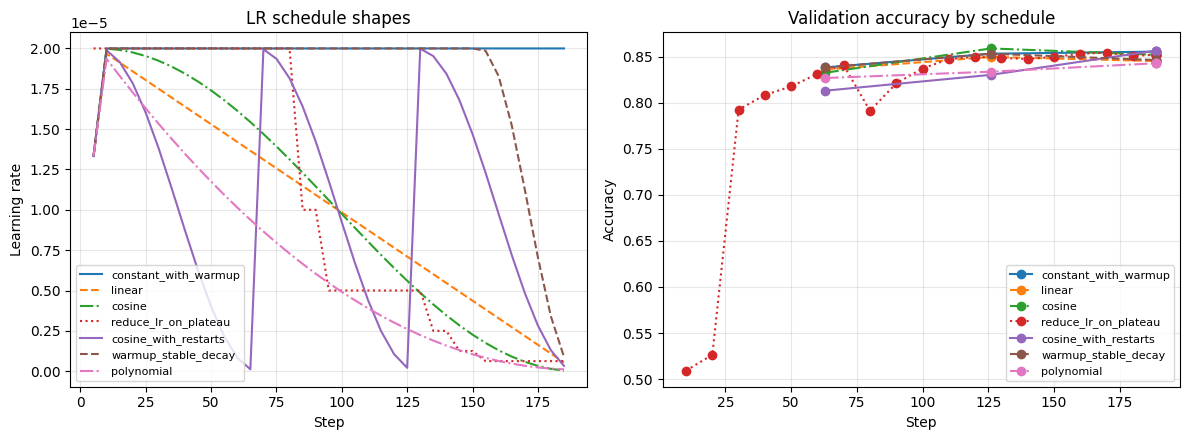

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

STYLES = ["-", "--", "-.", ":"]      # flat schedules overlap; vary the dash pattern

for i, (name, _) in enumerate(SCHEDULERS):
    ls = STYLES[i % len(STYLES)]

    s, l = get_lr_curve(sched_trainers[name])
    axes[0].plot(s, l, linestyle=ls, label=name)

    _, _, vs, va = get_loss_curves(sched_trainers[name])
    axes[1].plot(vs, va, linestyle=ls, marker="o", label=name)

axes[0].set_title("LR schedule shapes")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Learning rate")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Validation accuracy by schedule")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Accuracy")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.close(fig)        # prevents the end-of-cell re-render

### <font color="purple">**Comparison of all five approaches**</font>

In [37]:
summary = pd.DataFrame(RESULTS).sort_values("accuracy", ascending=False).reset_index(drop=True)
print(summary.to_string(index=False))

           approach                 config  accuracy  f1_macro  eval_loss  trainable_M  trainable_%  steps  minutes
         schedulers   cosine_with_restarts    0.8567    0.8566     0.3585         67.0        100.0    189     0.10
         schedulers   constant_with_warmup    0.8555    0.8553     0.4135         67.0        100.0    189     0.10
         schedulers                 cosine    0.8521    0.8520     0.3613         67.0        100.0    189     0.10
         schedulers   reduce_lr_on_plateau    0.8521    0.8521     0.3659         67.0        100.0    189     0.17
   encoder-freezing               freeze-1    0.8475    0.8474     0.3673         59.9         89.4    189     0.09
         schedulers    warmup_stable_decay    0.8463    0.8459     0.4732         67.0        100.0    189     0.10
              1-SFT      linear (baseline)    0.8452    0.8451     0.3799         67.0        100.0    189     0.12
   encoder-freezing               freeze-0    0.8452    0.8451     0.379

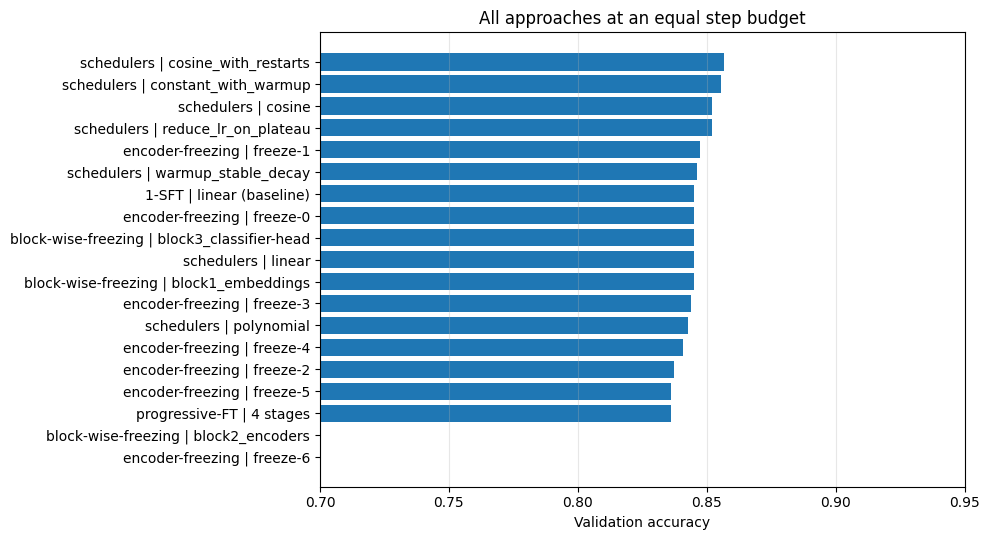

In [38]:
plt.figure(figsize=(10, 5.5))
labels = summary["approach"] + " | " + summary["config"]
plt.barh(labels, summary["accuracy"])
plt.xlim(0.70, 0.95)
plt.title("All approaches at an equal step budget")
plt.xlabel("Validation accuracy")
plt.gca().invert_yaxis()
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### **Summary**

* **SFT** updates every parameter and gives the strongest accuracy on SST-2, but it is also the most expensive in trainable parameters and the most sensitive to the learning-rate schedule.
* **Freezing the bottom encoder layers** costs very little accuracy while cutting the trainable parameters sharply — training only the top two or three blocks recovers most of the full fine-tuning result. Freezing the **entire** encoder, however, drops accuracy clearly, which shows the frozen pretrained features alone are not sufficient for this task.
* **Progressive fine-tuning** reaches roughly the same accuracy as SFT under an equal step budget. Gradual unfreezing is designed for **small or domain-shifted** target sets where full fine-tuning forgets the pretrained representation; SST-2 is large, in-domain for `distilbert-base-uncased` and only six blocks deep, so there is little to forget.
* Among the **LR schedulers**, `linear`, `cosine` and `polynomial` usually cluster within a few tenths of a point, while `constant_with_warmup` tends to be slightly behind because the learning rate never anneals near the end of training.
* Differences of **0.2–0.4 accuracy points between these runs are inside seed noise**. Any claim that one approach beats another should be repeated over 3–5 seeds before being reported.

### **Future Directions**

1. **Repeat every configuration over several seeds** and report mean ± standard deviation, so that real differences can be separated from run-to-run variance.

2. **Reduce the training set to a few hundred examples** (`N_TRAIN = 500`, more epochs) to study the low-resource regime, where freezing and progressive schedules are expected to become competitive with or better than full fine-tuning.

3. **Repeat the comparison on a domain-shifted dataset** — for example a clinical or biomedical classification task — where the gap between the pretraining corpus and the target task is much larger.

4. **Compare against parameter-efficient methods** such as LoRA, adapters or BitFit, which target the same accuracy vs trainable-parameter trade-off as Approach 2.

5. **Scale to deeper encoders** (BERT-base, RoBERTa-large) to test whether the bottom-freezing findings still hold when the encoder has 12 or 24 blocks instead of 6.

In [39]:
##-------------END------------------------##